# FusionGait — Clasificación de Fase de Marcha con TinyML

Notebook de entrenamiento, cuantización y exportación de un modelo 1D-CNN para clasificar las cuatro fases de la marcha (`loading`, `midstance`, `terminal`, `swing`) a partir de datos IMU de dos sensores (tobillo + pierna) montados en Arduino Nano 33 BLE Sense Rev2.

**Pipeline:**
1. Carga y limpieza  
2. EDA  
3. Alineación multi-sensor  
4. Segmentación en ventanas  
5. Split sin data leakage  
6. Modelo 1D-CNN  
7. Entrenamiento  
8. Evaluación  
9. TFLite float32 + int8  
10. Header C para Arduino  
11. Parámetros del escalador  
12. Plantilla de firmware

## 1. Configuración

Importaciones, constantes globales y semillas aleatorias para reproducibilidad.

In [181]:
import os
import glob
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
# import tensorflow as tf
# from tensorflow.keras.layers import (
#     Input, Conv1D, BatchNormalization, GlobalAveragePooling1D,
#     Dense, Dropout
# )
# from tensorflow.keras.models import Model
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# from tensorflow.keras.utils import to_categorical

warnings.filterwarnings('ignore')

# ── Constants ──────────────────────────────────────────────────────────────
WINDOW_SIZE = 50          # samples per window (0.5 s @ 100 Hz)
STEP        = 25          # hop size (50 % overlap)
SAMPLE_HZ   = 100         # IMU sample rate
N_SENSORS   = 3           # Total de sensores (1 master + N_SLAVES)
                          # Cambiar a 3 si usas 2 esclavos
SENSOR_IDS  = list(range(1, N_SENSORS + 1))  # [1,2] o [1,2,3]
N_FEATURES  = 6 * 2  # ax,ay,az,gx,gy,gz por sensor

DATA_DIR   = os.path.abspath('../../data/raw')
MODELS_DIR = os.path.abspath('../models')
os.makedirs(MODELS_DIR, exist_ok=True)

PHASES   = ['loading', 'midstance', 'terminal', 'swing']
PHASE2ID = {p: i for i, p in enumerate(PHASES)}
N_CLASSES = len(PHASES)

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
# tf.random.set_seed(SEED)

# print(f'TensorFlow: {tf.__version__}')
print(f'Data dir   : {DATA_DIR}')
print(f'Models dir : {MODELS_DIR}')
print(f'Phases     : {PHASE2ID}')
print(f'Features/window: {WINDOW_SIZE} samples × {N_FEATURES} channels')

Data dir   : /Users/diegovillaba/Code/FusionGait/data/raw
Models dir : /Users/diegovillaba/Code/FusionGait/training/models
Phases     : {'loading': 0, 'midstance': 1, 'terminal': 2, 'swing': 3}
Features/window: 50 samples × 12 channels


## 2. Carga y limpieza de datos

Se cargan todos los CSV en `data/raw/`, se descartan filas cuya fase no pertenezca a las cuatro fases válidas (p.ej. `'none'` o vacías), y se normaliza el tipo de `sensor_id` a entero.

**Nota sobre los archivos:** El dataset contiene múltiples archivos por trial/sensor (distintos timestamps en el nombre), que corresponden a distintas grabaciones del mismo trial. Se concatenan todos y se usa `trial_id` + `subject_id` como identificadores.
El trial `0012` y el sujeto `s001` se incluyen como datos adicionales de entrenamiento.

In [182]:
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print(f'Archivos CSV encontrados: {len(csv_files)}')

dfs = []
for fp in csv_files:
    try:
        df_ = pd.read_csv(fp)
        df_['source_file'] = os.path.basename(fp)
        dfs.append(df_)
    except Exception as e:
        print(f'  WARN: no se pudo leer {fp}: {e}')

Archivos CSV encontrados: 182


In [183]:
raw = pd.concat(dfs, ignore_index=True)
print(f'Filas totales (sin filtrar): {len(raw):,}')

# ── Limpieza ───────────────────────────────────────────────────────────────
raw['sensor_id'] = pd.to_numeric(raw['sensor_id'], errors='coerce').astype('Int64')
raw['timestamp_arduino_ms'] = pd.to_numeric(raw['timestamp_arduino_ms'], errors='coerce')
raw['timestamp_pc_ms']      = pd.to_numeric(raw['timestamp_pc_ms'],      errors='coerce')
for col in ['ax','ay','az','gx','gy','gz']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

Filas totales (sin filtrar): 305,850


In [184]:
subjects = raw['subject_id'].unique()
print(f" Sujetos explorados {subjects}")


 Sujetos explorados <StringArray>
['AHC', 'FIJTB', 'FJTB', 'HHYSS', 'MADCF', 'MBYRA', 'diego']
Length: 7, dtype: str


In [185]:
# Keep only valid phases and sensors
df = raw[raw['phase'].isin(PHASES)].copy()
df = df[df['sensor_id'].isin(SENSOR_IDS)].copy()
df = df.dropna(subset=['ax','ay','az','gx','gy','gz','timestamp_pc_ms'])
df['trial_id'] = df['trial_id'].astype(str)  # normalise: 12 -> '12', 't001' -> 't001'
df = df.reset_index(drop=True)

# Unified trial key that works across subjects
df['trial_key'] = df['subject_id'].astype(str) + '_' + df['trial_id'].astype(str)

print(f'Filas tras filtrar : {len(df):,}')
print(f'Distribucion de fases:')
print(df['phase'].value_counts().to_string())
print(f'Trials unicos: {sorted(df["trial_key"].unique())}')
print(f'Sensores unicos: {sorted(df["sensor_id"].unique())}')

Filas tras filtrar : 305,848
Distribucion de fases:
phase
swing        120877
loading       77049
midstance     58968
terminal      48954
Trials unicos: ['AHC_t001', 'AHC_t002', 'AHC_t003', 'AHC_t004', 'AHC_t005', 'AHC_t006', 'AHC_t007', 'AHC_t008', 'AHC_t009', 'AHC_t010', 'FIJTB_t001', 'FIJTB_t002', 'FIJTB_t003', 'FIJTB_t004', 'FIJTB_t005', 'FIJTB_t006', 'FIJTB_t007', 'FIJTB_t008', 'FIJTB_t009', 'FIJTB_t010', 'FJTB_t001', 'FJTB_t002', 'FJTB_t003', 'FJTB_t004', 'FJTB_t005', 'FJTB_t006', 'FJTB_t007', 'FJTB_t008', 'FJTB_t009', 'FJTB_t010', 'HHYSS_t001', 'HHYSS_t002', 'HHYSS_t003', 'HHYSS_t004', 'HHYSS_t005', 'HHYSS_t006', 'HHYSS_t007', 'HHYSS_t008', 'HHYSS_t009', 'HHYSS_t010', 'HHYSS_t011', 'MADCF_t001', 'MADCF_t002', 'MADCF_t003', 'MADCF_t004', 'MADCF_t005', 'MADCF_t007', 'MADCF_t008', 'MADCF_t009', 'MADCF_t010', 'MBYRA_t001', 'MBYRA_t002', 'MBYRA_t003', 'MBYRA_t004', 'MBYRA_t005', 'MBYRA_t006', 'MBYRA_t007', 'MBYRA_t008', 'MBYRA_t009', 'MBYRA_t010', 'diego_t001', 'diego_t002', 'diego_t

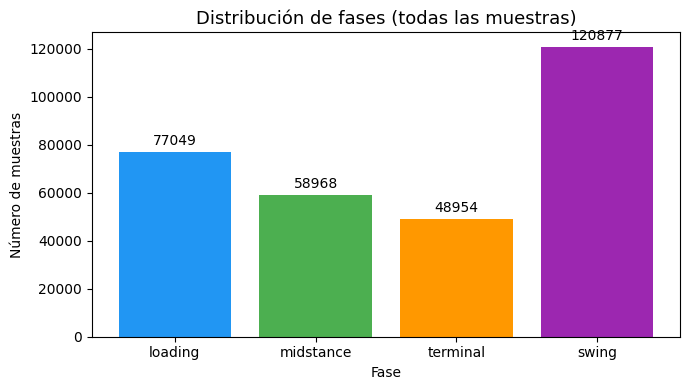

Ratio clase mayoritaria / minoritaria: 2.5x


In [186]:
# ── Visualización distribución de fases ──────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['phase'].value_counts().reindex(PHASES)
bars = ax.bar(PHASES, counts.values,
              color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('Distribución de fases (todas las muestras)', fontsize=13)
ax.set_ylabel('Número de muestras')
ax.set_xlabel('Fase')
plt.tight_layout()
plt.show()
print(f'Ratio clase mayoritaria / minoritaria: {counts.max()/counts.min():.1f}x')

## 3. Exploración (EDA)

Visualizamos la señal `ax` de ambos sensores para un trial representativo, con la fase coloreada para ver la variabilidad temporal.

Analizaremos sujeto por sujeto para encontrar inconsistencias

In [187]:
from ploting import graficar_eda_trial

#### AHC

In [188]:
# 1. Filtrar por sujeto y obtener trials disponibles
# Modifica el sensor_id a 1 donde se cumplan ambas condiciones
df.loc[(df['subject_id'] == 'AHC') & (df['placement'] == 'tobillo'), 'sensor_id'] = 1
df_AHC = df[df['subject_id'] == 'AHC']
trials_disponibles = df_AHC['trial_key'].unique()
sensores = df_AHC['sensor_id'].unique()

In [189]:
df_AHC.head()


,timestamp_pc_ms,timestamp_arduino_ms,sensor_id,placement,phase,ax,ay,az,gx,gy,gz,trial_id,subject_id,source_file,trial_key
0,2527294398,433865,1,tobillo,loading,-0.0409,0.9708,-0.1532,0.7324,-2.0752,0.1831,t001,AHC,AHC_t001_s1_tobillo_20260520_165609.csv,AHC_t001
1,2527294402,433881,1,tobillo,loading,-0.0433,0.9683,-0.1488,0.6714,-1.5869,0.3052,t001,AHC,AHC_t001_s1_tobillo_20260520_165609.csv,AHC_t001
2,2527294449,433897,1,tobillo,loading,-0.0427,0.9670,-0.1482,0.4272,-0.4272,0.3662,t001,AHC,AHC_t001_s1_tobillo_20260520_165609.csv,AHC_t001
3,2527294449,433913,1,tobillo,loading,-0.0444,0.9686,-0.1497,0.2441,-0.1221,0.3662,t001,AHC,AHC_t001_s1_tobillo_20260520_165609.csv,AHC_t001
4,2527294450,433929,1,tobillo,loading,-0.0406,0.9722,-0.1514,0.1831,0.0000,0.4272,t001,AHC,AHC_t001_s1_tobillo_20260520_165609.csv,AHC_t001


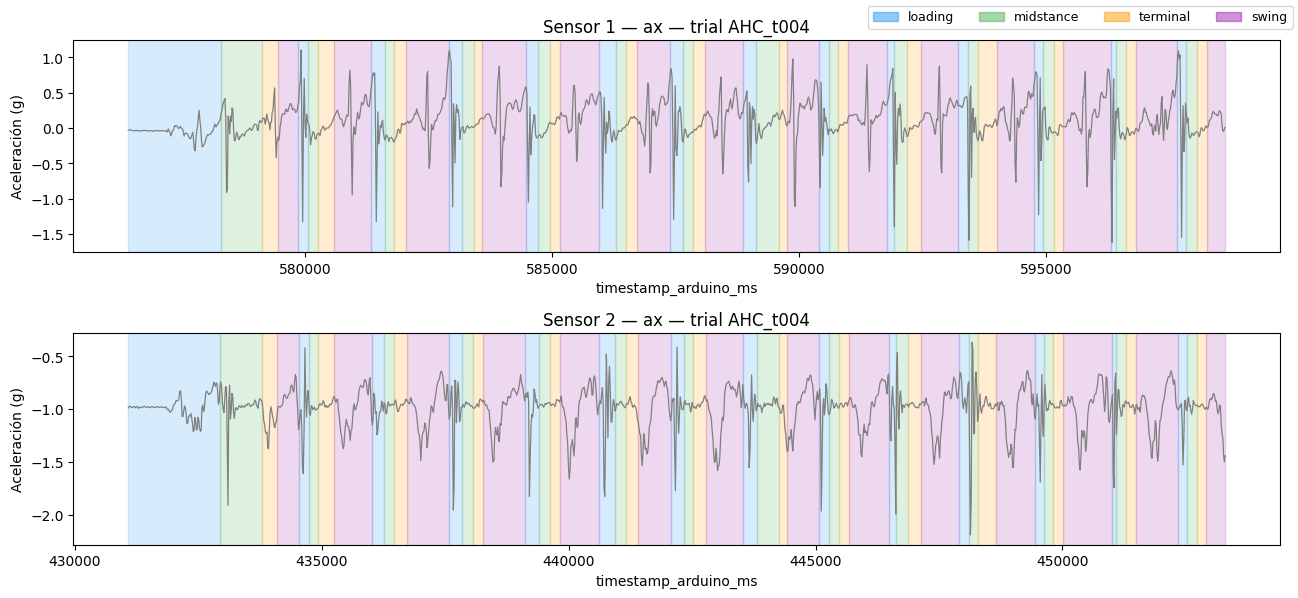

In [190]:
graficar_eda_trial(df, 'AHC', 'AHC_t004', sensores=[1, 2])

### FIJTB

In [191]:
## TODO: Hay que invertir estas mediciones

In [192]:
# 1. Filtrar por sujeto y obtener trials disponibles
# Modifica el sensor_id a 1 donde se cumplan ambas condiciones
df.loc[(df['subject_id'] == 'FIJTB') & (df['placement'] == 'pierna'), 'sensor_id'] = 1
df_FIJTB = df[df['subject_id'] == 'FIJTB']
trials_disponibles = df_AHC['trial_key'].unique()

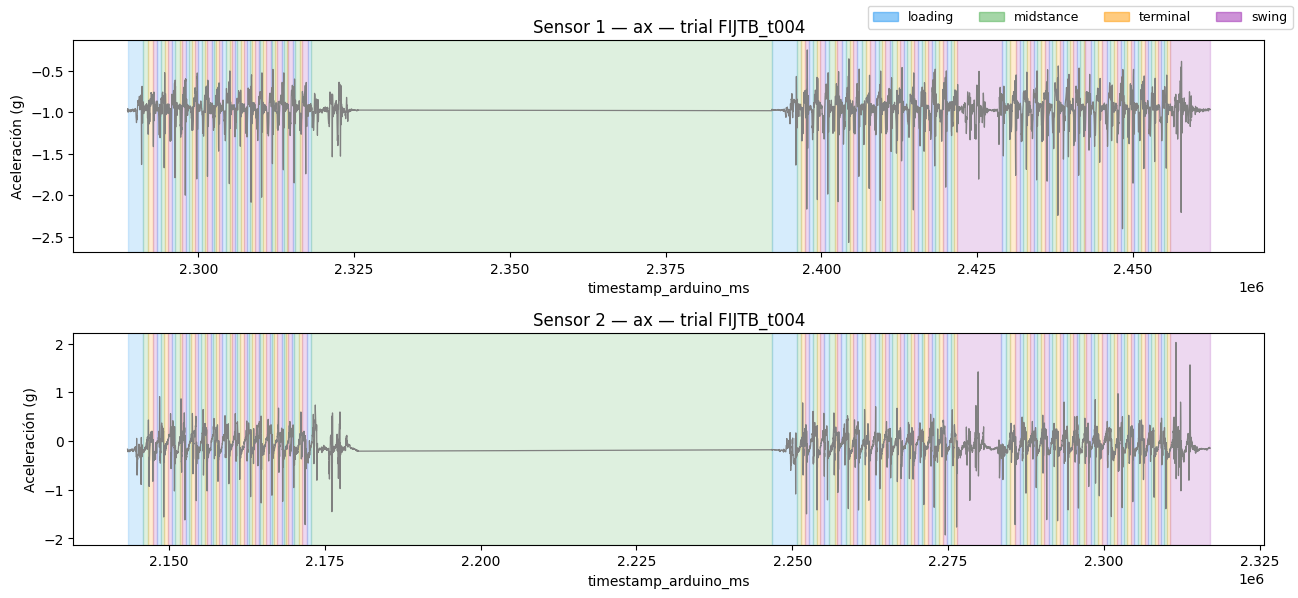

In [193]:
graficar_eda_trial(df, 'FIJTB', 'FIJTB_t004', sensores=[1, 2])

### FJTB

In [194]:
# 1. Filtrar por sujeto y obtener trials disponibles
# Modifica el sensor_id a 1 donde se cumplan ambas condiciones
df.loc[(df['subject_id'] == 'FJTB') & (df['placement'] == 'pierna'), 'sensor_id'] = 1
df_FJTB = df[df['subject_id'] == 'FJTB']
trials_disponibles = df_FJTB['trial_key'].unique()
sensores = df_FJTB['sensor_id'].unique()

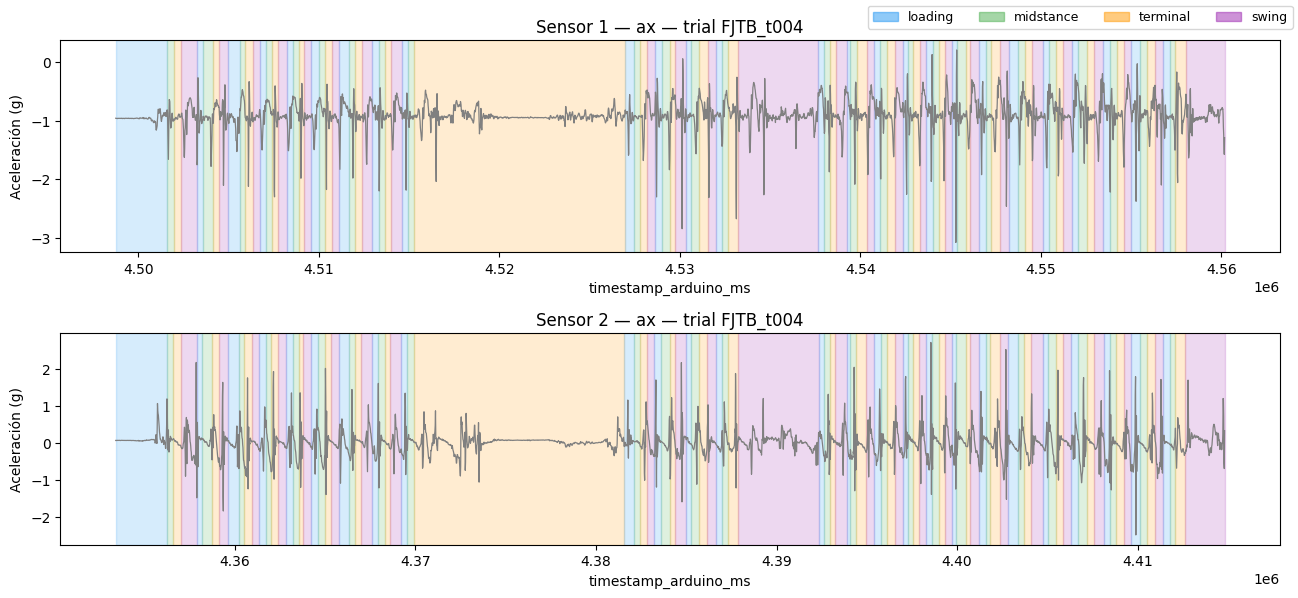

In [195]:
graficar_eda_trial(df, 'FJTB', 'FJTB_t004', sensores=[1, 2])

### HHYSS

In [196]:
# 1. Filtrar por sujeto y obtener trials disponibles
# Modifica el sensor_id a 1 donde se cumplan ambas condiciones
df.loc[(df['subject_id'] == 'HHYSS') & (df['placement'] == 'pierna'), 'sensor_id'] = 1
df_HHYSS = df[df['subject_id'] == 'HHYSS']
trials_disponibles = df_HHYSS['trial_key'].unique()
sensores = df_HHYSS['sensor_id'].unique()

Trial no especificado o no encontrado. Usando: HHYSS_t001


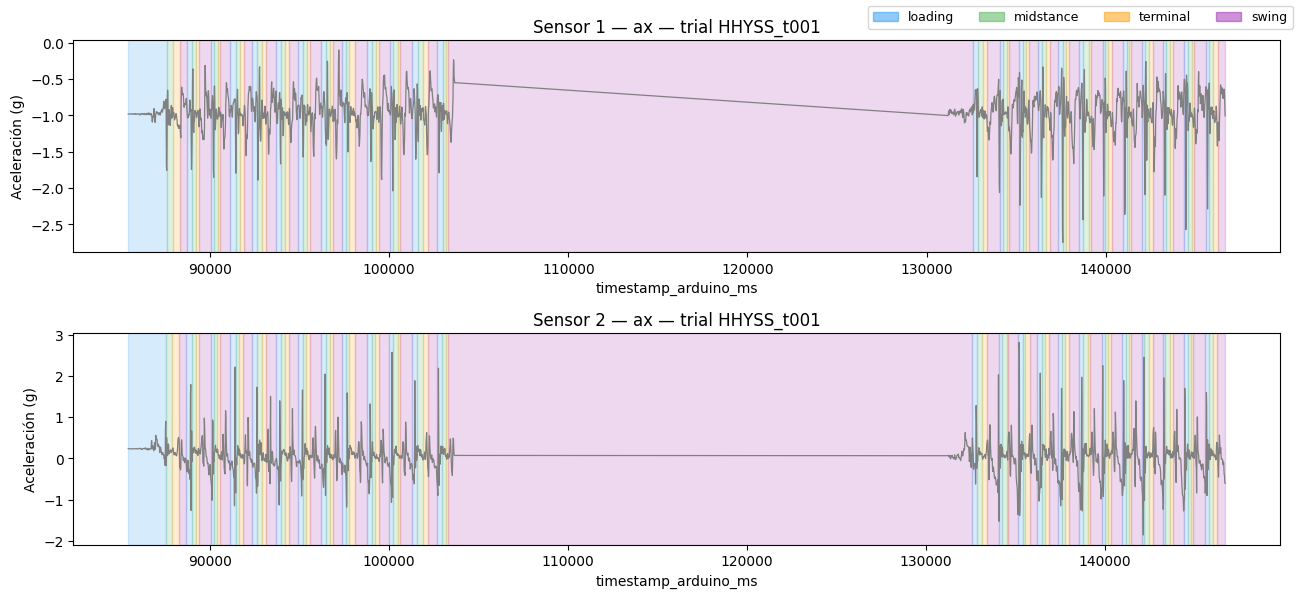

In [197]:
graficar_eda_trial(df, 'HHYSS', 'FJTB_t004', sensores=[1, 2])

### MADCF

In [198]:
# 1. Filtrar por sujeto y obtener trials disponibles
# Modifica el sensor_id a 1 donde se cumplan ambas condiciones
df.loc[(df['subject_id'] == 'MADCF') & (df['placement'] == 'pierna'), 'sensor_id'] = 1
df_MADCF = df[df['subject_id'] == 'MADCF']
trials_disponibles = df_MADCF['trial_key'].unique()
sensores = df_MADCF['sensor_id'].unique()

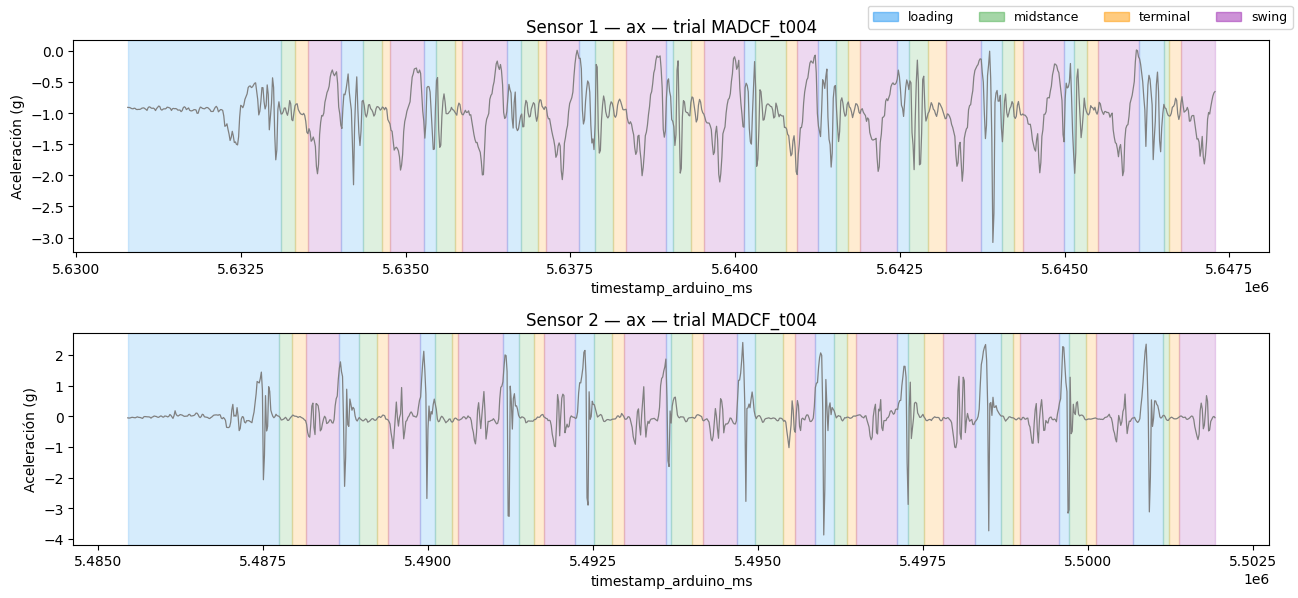

In [199]:
graficar_eda_trial(df, 'MADCF', 'MADCF_t004', sensores=[1, 2])

### MBYRA

In [200]:
# 1. Filtrar por sujeto y obtener trials disponibles
# Modifica el sensor_id a 1 donde se cumplan ambas condiciones
df.loc[(df['subject_id'] == 'MBYRA') & (df['placement'] == 'tobillo'), 'sensor_id'] = 1
df_MBYRA = df[df['subject_id'] == 'MBYRA']
trials_disponibles = df_MBYRA['trial_key'].unique()
sensores = df_MBYRA['sensor_id'].unique()

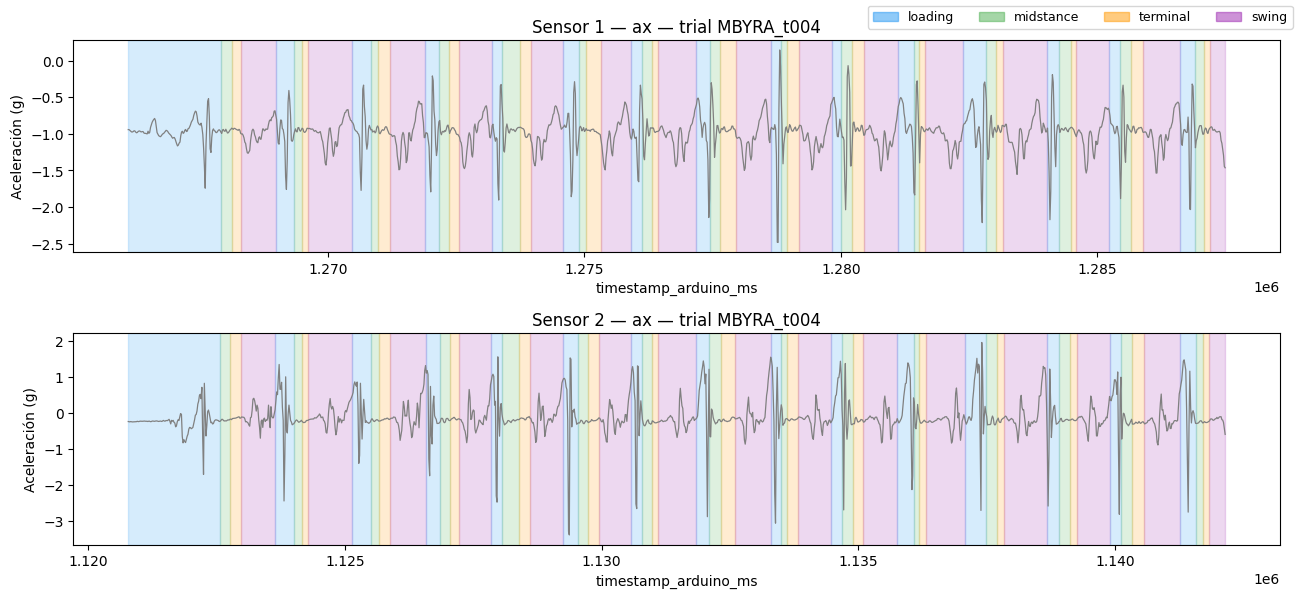

In [201]:
graficar_eda_trial(df, 'MBYRA', 'MBYRA_t004', sensores=[1, 2])

### Diego

In [202]:
# 1. Filtrar por sujeto y obtener trials disponibles
# Modifica el sensor_id a 1 donde se cumplan ambas condiciones
df.loc[(df['subject_id'] == 'diego') & (df['placement'] == 'tobillo'), 'sensor_id'] = 1
df.loc[(df['subject_id'] == 'diego') & (df['placement'] == 'pierna'), 'sensor_id'] = 2

df_diego = df[df['subject_id'] == 'diego']
trials_disponibles = df_diego['trial_key'].unique()
sensores = df_diego['sensor_id'].unique()

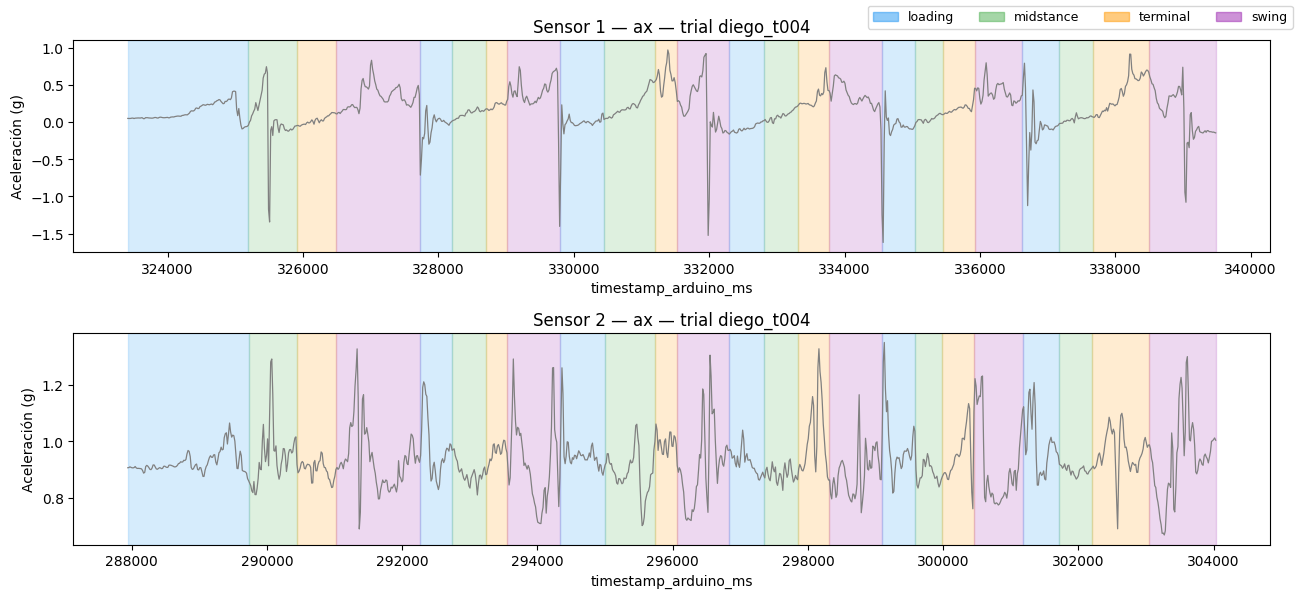

In [203]:
graficar_eda_trial(df, 'diego', 'diego_t004', sensores=[1, 2])


## Histogramas globales

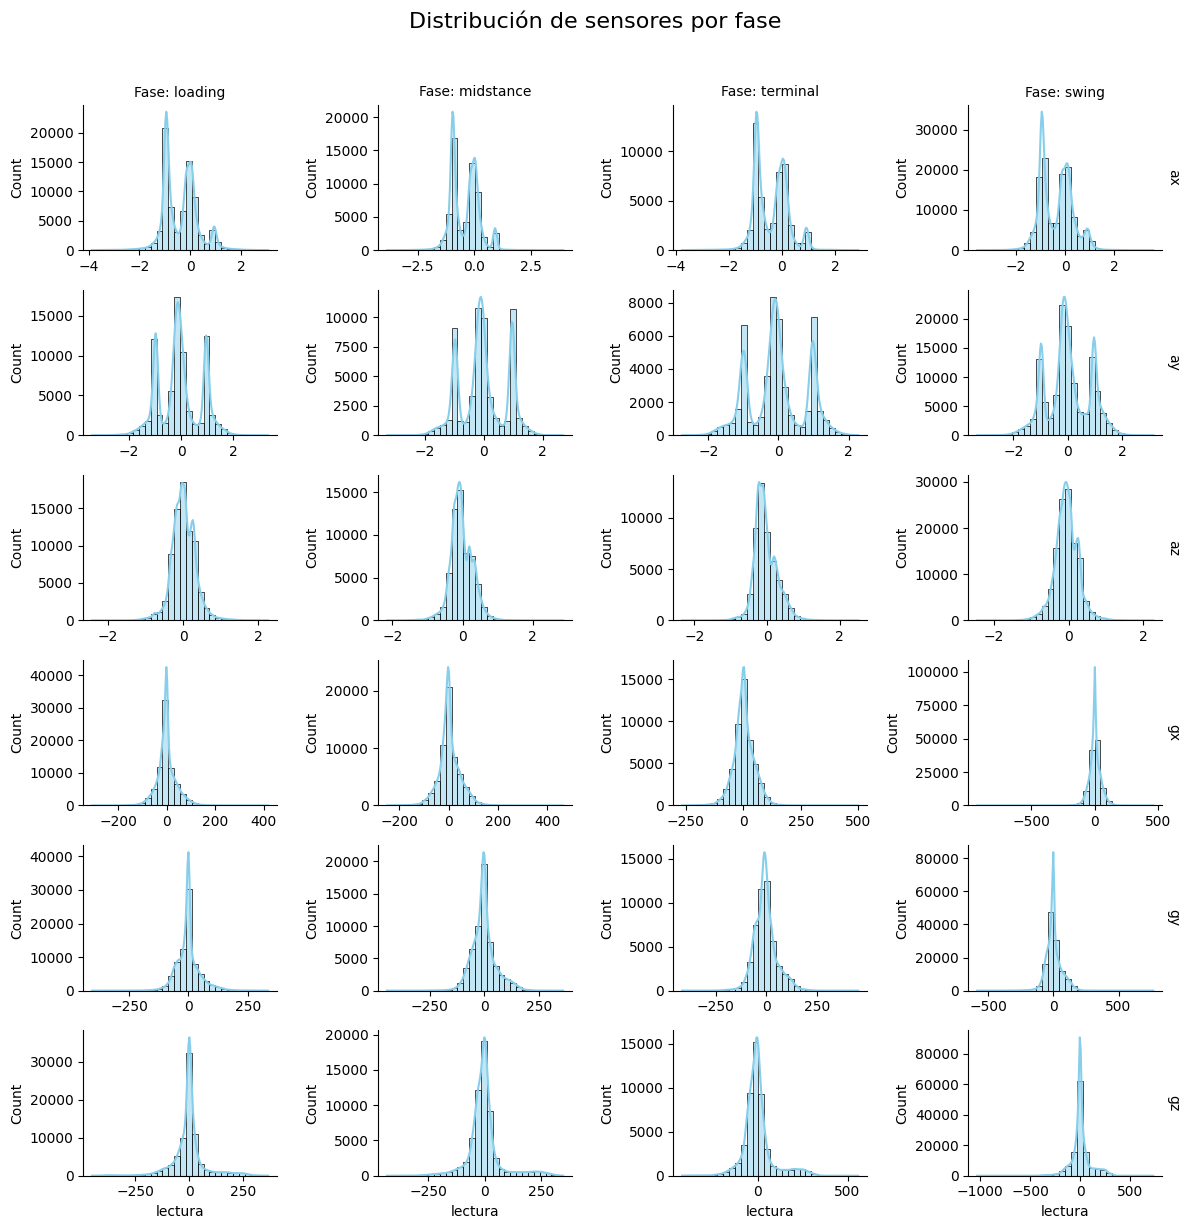

In [204]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de columnas que quieres visualizar
columns = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

# 1. Ajustar el dataframe para "derretirlo" (melt) y facilitar el ploteo
# Esto transforma las columnas en una sola columna 'variable' y otra 'value'
df_melted = df.melt(id_vars=['phase'], value_vars=columns, 
                    var_name='sensor', value_name='lectura')

# 2. Configurar FacetGrid
# Mapeamos 'phase' a las columnas y 'sensor' a las filas (o viceversa)
g = sns.FacetGrid(df_melted, row='sensor', col='phase', 
                  margin_titles=True, sharex=False, sharey=False, height=2, aspect=1.5)

# 3. Dibujar el histograma
g.map(sns.histplot, 'lectura', kde=True, bins=30, color='skyblue')

# Ajustes estéticos
g.set_titles(row_template='{row_name}', col_template='Fase: {col_name}')
g.fig.suptitle('Distribución de sensores por fase', y=1.02, fontsize=16)

plt.tight_layout()
plt.show()

## 4. Alineación multi-sensor

Los dos sensores tienen sus propios timestamps de Arduino (distintos relojes). Los alineamos por `trial_key` usando un merge por proximidad temporal (tolerancia 15 ms). El ground-truth de fase se toma del sensor 1 (tobillo).

La función es extensible a 3 sensores agregando `sensor_ids=[1,2,3]`.

In [205]:
IMU_COLS = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

def align_sensors(df_in, sensor_ids=None):
    """Merge sensor streams per trial by nearest PC timestamp (tolerance 15 ms).

    Uses timestamp_pc_ms (wall-clock assigned by the PC logger) so that
    independent Arduino clocks — which start at different boot offsets — do
    not prevent alignment.

    Parameters
    ----------
    df_in      : DataFrame with all raw rows
    sensor_ids : list of int, default [1, 2]

    Returns
    -------
    DataFrame with columns: trial_key, phase, ax_s1..gz_sN
    """
    if sensor_ids is None:
        sensor_ids = [1, 2]

    TOLERANCE_MS = 15
    all_merged = []

    for trial_key, grp in df_in.groupby('trial_key'):
        # 🟢 NUEVO: Extraer el subject_id de este trial antes de separar
        subject_id = grp['subject_id'].iloc[0] if 'subject_id' in grp.columns else 'Desconocido'
        
        sensor_dfs = {}
        for sid in sensor_ids:
            s = grp[grp['sensor_id'] == sid].copy()
            s = s.sort_values('timestamp_pc_ms').reset_index(drop=True)
            sensor_dfs[sid] = s

        if any(len(v) < 10 for v in sensor_dfs.values()):
            print(f'  SKIP {trial_key}: insuficientes muestras en algún sensor')
            continue

        ref_sid = sensor_ids[0]
        # 🟢 MODIFICADO: Incluimos también 'timestamp_arduino_ms' del sensor de referencia
        ref = sensor_dfs[ref_sid][['timestamp_pc_ms', 'timestamp_arduino_ms', 'phase'] + IMU_COLS].copy()
        ref = ref.rename(columns={c: f'{c}_s{ref_sid}' for c in IMU_COLS})
        merged = ref.copy()

        for sid in sensor_ids[1:]:
            other = sensor_dfs[sid][['timestamp_pc_ms'] + IMU_COLS].copy()
            other = other.rename(columns={c: f'{c}_s{sid}' for c in IMU_COLS})
            other = other.sort_values('timestamp_pc_ms').reset_index(drop=True)

            merged = pd.merge_asof(
                merged.sort_values('timestamp_pc_ms'),
                other.sort_values('timestamp_pc_ms'),
                on='timestamp_pc_ms',
                direction='nearest',
                tolerance=TOLERANCE_MS
            )

        feat_cols = [f'{c}_s{sid}' for sid in sensor_ids for c in IMU_COLS]
        merged = merged.dropna(subset=feat_cols)
        if merged.empty:
            print(f'  SKIP {trial_key}: sin alineación exitosa (tolerancia {TOLERANCE_MS}ms)')
            continue

        # 🟢 NUEVO: Inyectar subject_id y trial_key al dataframe intermedio
        merged['trial_key'] = trial_key
        merged['subject_id'] = subject_id
        
        # 🟢 MODIFICADO: Agregamos las columnas de control a la salida final
        all_merged.append(merged[['subject_id', 'trial_key', 'timestamp_arduino_ms', 'phase'] + feat_cols])

    if not all_merged:
        raise ValueError('align_sensors: ningún trial pudo alinearse.')

    result = pd.concat(all_merged, ignore_index=True)
    return result


df_aligned = align_sensors(df, sensor_ids=[1,2])
print(f'Shape tras alineación: {df_aligned.shape}')
print(f'Columnas: {df_aligned.columns.tolist()}')
print(f'Fases alineadas:')
print(df_aligned['phase'].value_counts().reindex(PHASES).to_string())
print(f'Trials alineados: {sorted(df_aligned["trial_key"].unique())}')

  SKIP FJTB_t006: insuficientes muestras en algún sensor
  SKIP FJTB_t007: insuficientes muestras en algún sensor
  SKIP FJTB_t008: insuficientes muestras en algún sensor
  SKIP FJTB_t009: insuficientes muestras en algún sensor
  SKIP FJTB_t010: insuficientes muestras en algún sensor
Shape tras alineación: (132954, 16)
Columnas: ['subject_id', 'trial_key', 'timestamp_arduino_ms', 'phase', 'ax_s1', 'ay_s1', 'az_s1', 'gx_s1', 'gy_s1', 'gz_s1', 'ax_s2', 'ay_s2', 'az_s2', 'gx_s2', 'gy_s2', 'gz_s2']
Fases alineadas:
phase
loading      32546
midstance    23697
terminal     21582
swing        55129
Trials alineados: ['AHC_t001', 'AHC_t002', 'AHC_t003', 'AHC_t004', 'AHC_t005', 'AHC_t006', 'AHC_t007', 'AHC_t008', 'AHC_t009', 'AHC_t010', 'FIJTB_t001', 'FIJTB_t002', 'FIJTB_t003', 'FIJTB_t004', 'FIJTB_t005', 'FIJTB_t006', 'FIJTB_t007', 'FIJTB_t008', 'FIJTB_t009', 'FIJTB_t010', 'FJTB_t001', 'FJTB_t002', 'FJTB_t003', 'FJTB_t004', 'FJTB_t005', 'HHYSS_t001', 'HHYSS_t002', 'HHYSS_t003', 'HHYSS_t004', '

Fase [loading]: Eliminados 74 bloques anómalos.
Fase [midstance]: Eliminados 14 bloques anómalos.
Fase [terminal]: Eliminados 22 bloques anómalos.
Fase [swing]: Eliminados 58 bloques anómalos.

--- Resumen de Limpieza de Muestras ---
Muestras originales en df_aligned: 132954
Muestras limpias en df_aligned_clean: 96128
Filas totales eliminadas (ruido/outliers): 36826


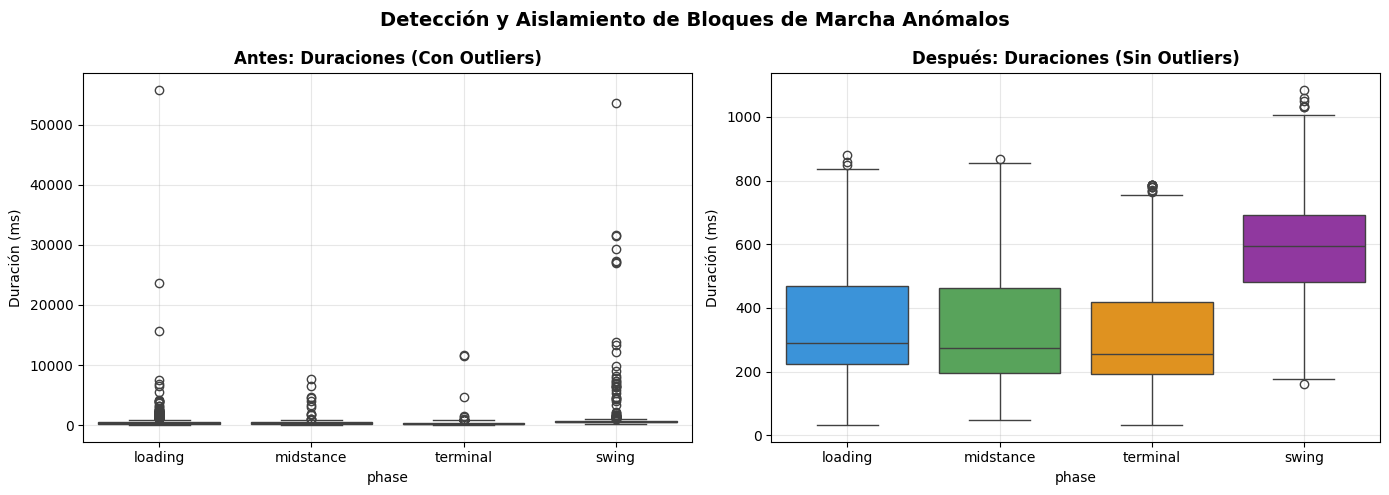

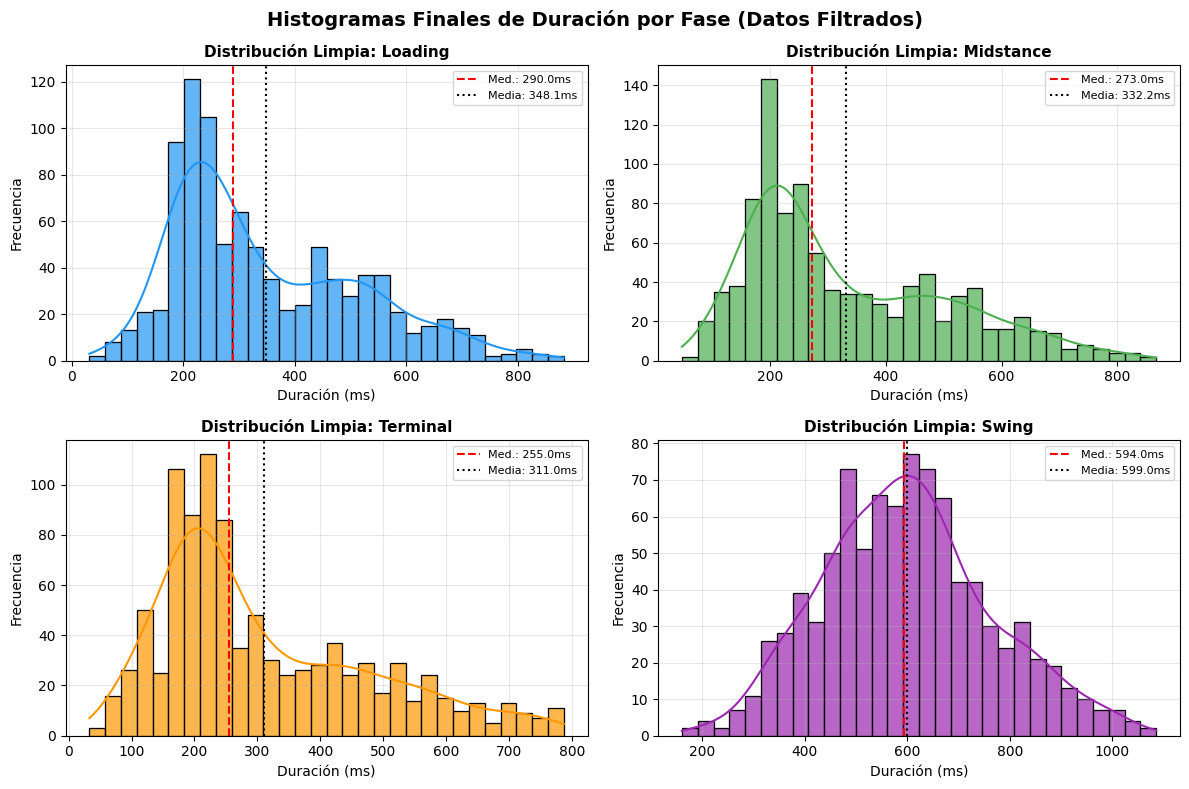

In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Colores originales de tus fases
PHASE_COLORS = {
    'loading': '#2196F3', 
    'midstance': '#4CAF50',
    'terminal': '#FF9800', 
    'swing': '#9C27B0'
}

# Asegurar orden cronológico para evaluar correctamente la continuidad temporal
df_aligned = df_aligned.sort_values(['subject_id', 'trial_key', 'timestamp_arduino_ms'])

# ────────────────────────────────────────────────────────────────────────
# STEP 1: Detectar bloques continuos de fase
# ────────────────────────────────────────────────────────────────────────
phase_changed = (df_aligned['phase'] != df_aligned['phase'].shift()) | \
                (df_aligned['trial_key'] != df_aligned['trial_key'].shift()) | \
                (df_aligned['subject_id'] != df_aligned['subject_id'].shift())

df_aligned['phase_block_id'] = phase_changed.cumsum()

# Calcular la duración temporal de cada uno de estos bloques individuales
df_duraciones = df_aligned.groupby(['phase_block_id', 'phase', 'subject_id', 'trial_key']).agg(
    duracion_ms=('timestamp_arduino_ms', lambda x: x.max() - x.min())
).reset_index()

# Excluir ruidos instantáneos de 0 ms antes del análisis formal de outliers
df_duraciones = df_duraciones[df_duraciones['duracion_ms'] > 0]


# ────────────────────────────────────────────────────────────────────────
# STEP 2: Identificar los IDs de bloques válidos usando el método IQR
# ────────────────────────────────────────────────────────────────────────
bloques_validos_ids = []
df_duraciones_clean_lista = []

for fase in df_duraciones['phase'].unique():
    df_fase = df_duraciones[df_duraciones['phase'] == fase].copy()
    
    Q1 = df_fase['duracion_ms'].quantile(0.25)
    Q3 = df_fase['duracion_ms'].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Filtrar las duraciones que están dentro del rango correcto
    df_fase_filtrado = df_fase[(df_fase['duracion_ms'] >= limite_inferior) & 
                               (df_fase['duracion_ms'] <= limite_superior)]
    
    df_duraciones_clean_lista.append(df_fase_filtrado)
    
    # Guardar los IDs de los bloques que pasaron el filtro de calidad
    bloques_validos_ids.extend(df_fase_filtrado['phase_block_id'].tolist())
    
    eliminados = len(df_fase) - len(df_fase_filtrado)
    print(f"Fase [{fase}]: Eliminados {eliminados} bloques anómalos.")

# Dataframe de duraciones para el gráfico (después de limpiar)
df_duraciones_clean = pd.concat(df_duraciones_clean_lista)


# ────────────────────────────────────────────────────────────────────────
# STEP 3: Filtrado Directo sobre df_aligned (Limpieza para tu TinyML)
# ────────────────────────────────────────────────────────────────────────
# Conservamos únicamente las filas que pertenecen a los bloques de tiempo aprobados
df_aligned_clean = df_aligned[df_aligned['phase_block_id'].isin(bloques_validos_ids)].copy()

# Eliminar la columna auxiliar para dejar el DataFrame impecable
df_aligned_clean = df_aligned_clean.drop(columns=['phase_block_id'])

print(f"\n--- Resumen de Limpieza de Muestras ---")
print(f"Muestras originales en df_aligned: {len(df_aligned)}")
print(f"Muestras limpias en df_aligned_clean: {len(df_aligned_clean)}")
print(f"Filas totales eliminadas (ruido/outliers): {len(df_aligned) - len(df_aligned_clean)}")


# ────────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN 1: Comparación de Box Plots
# ────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

sns.boxplot(data=df_duraciones, x='phase', y='duracion_ms', ax=axes[0], palette=PHASE_COLORS, hue='phase', legend=False)
axes[0].set_title('Antes: Duraciones (Con Outliers)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Duración (ms)')
axes[0].grid(True, alpha=0.3)

sns.boxplot(data=df_duraciones_clean, x='phase', y='duracion_ms', ax=axes[1], palette=PHASE_COLORS, hue='phase', legend=False)
axes[1].set_title('Después: Duraciones (Sin Outliers)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duración (ms)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Detección y Aislamiento de Bloques de Marcha Anómalos', fontsize=14, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()


# ────────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN 2: Histogramas Limpios
# ────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)
axes = axes.flatten()

fases_a_graficar = [p for p in PHASE_COLORS.keys() if p in df_duraciones_clean['phase'].unique()]

for i, fase in enumerate(fases_a_graficar):
    datos_fase = df_duraciones_clean[df_duraciones_clean['phase'] == fase]
    color_fase = PHASE_COLORS[fase]
    ax = axes[i]
    
    sns.histplot(data=datos_fase, x='duracion_ms', kde=True, color=color_fase, ax=ax, bins=30, alpha=0.7)
    
    mediana = datos_fase['duracion_ms'].median()
    media = datos_fase['duracion_ms'].mean()
    ax.axvline(mediana, color='red', linestyle='--', lw=1.5, label=f'Med.: {mediana:.1f}ms')
    ax.axvline(media, color='black', linestyle=':', lw=1.5, label=f'Media: {media:.1f}ms')
    
    ax.set_title(f'Distribución Limpia: {fase.capitalize()}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Duración (ms)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(len(fases_a_graficar), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histogramas Finales de Duración por Fase (Datos Filtrados)', fontsize=14, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Segmentación en ventanas

Deslizamos una ventana de 50 muestras con paso de 25 sobre cada trial de forma independiente (nunca cruzamos la frontera entre trials). La etiqueta de cada ventana es la fase mayoritaria dentro de ella.

In [207]:
# FEAT_COLS = [f'{c}_s{sid}' for sid in SENSOR_IDS for c in IMU_COLS]
FEAT_COLS =  ['ax_s1', 'ay_s1', 'az_s1', 'gx_s1', 'gy_s1', 'gz_s1', 'ax_s2', 'ay_s2', 'az_s2', 'gx_s2', 'gy_s2', 'gz_s2']
print(f'Feature columns ({len(FEAT_COLS)}): {FEAT_COLS}')


def make_windows(df_aligned, window=50, step=25, feat_cols=None, phase2id=None):
    """Slide a window over each trial and return (X, y, trial_keys).

    Parameters
    ----------
    df_aligned : aligned DataFrame
    window     : int, window length in samples
    step       : int, hop size
    feat_cols  : list of feature column names
    phase2id   : dict mapping phase name -> int

    Returns
    -------
    X : np.ndarray (n_windows, window, n_features)
    y : np.ndarray (n_windows,)  integer class labels
    trial_keys : list of str, which trial each window came from
    """
    if feat_cols is None:
        feat_cols = FEAT_COLS
    if phase2id is None:
        phase2id = PHASE2ID

    X_list, y_list, trial_list = [], [], []

    for trial_key, grp in df_aligned.groupby('trial_key'):
        grp = grp.reset_index(drop=True)
        n = len(grp)
        if n < window:
            print(f'  SKIP {trial_key}: solo {n} muestras (< window={window})')
            continue

        vals   = grp[feat_cols].values.astype(np.float32)  # (n, F)
        labels = grp['phase'].values

        for start in range(0, n - window + 1, step):
            end = start + window
            win_labels = labels[start:end]
            # Majority vote
            phase_counts = Counter(win_labels)
            majority = phase_counts.most_common(1)[0][0]
            if majority not in phase2id:
                continue  # skip windows dominated by unknown phases
            X_list.append(vals[start:end])  # (50, F)
            y_list.append(phase2id[majority])
            trial_list.append(trial_key)

    X = np.stack(X_list, axis=0)        # (n_windows, 50, F)
    y = np.array(y_list, dtype=np.int32)
    return X, y, trial_list


X_all, y_all, trial_keys_all = make_windows(
    df_aligned_clean, window=WINDOW_SIZE, step=STEP,
    feat_cols=FEAT_COLS, phase2id=PHASE2ID
)

print(f'X shape: {X_all.shape}  (ventanas × muestras × features)')
print(f'y shape: {y_all.shape}')
print('\nVentanas por fase:')
cnt = Counter(y_all)
for pid, pname in enumerate(PHASES):
    print(f'  {pname:12s}: {cnt[pid]:4d}')

Feature columns (12): ['ax_s1', 'ay_s1', 'az_s1', 'gx_s1', 'gy_s1', 'gz_s1', 'ax_s2', 'ay_s2', 'az_s2', 'gx_s2', 'gy_s2', 'gz_s2']
  SKIP FIJTB_t001: solo 44 muestras (< window=50)
X shape: (3751, 50, 12)  (ventanas × muestras × features)
y shape: (3751,)

Ventanas por fase:
  loading     :  716
  midstance   :  696
  terminal    :  559
  swing       : 1780


## 6b. Augmentación y balanceo de clases

### Por qué es necesario
Las fases tienen duraciones muy distintas en la marcha real:
- **Swing** (~60 % del ciclo) → clase dominante
- **Loading / Terminal** (~10 % cada una) → clases minoritarias

Con ventanas deslizantes eso se amplifica directamente en el conteo de ventanas.

### Estrategia
1. **Augmentación temporal** sobre clases minoritarias:
   - *Jitter*: ruido gaussiano σ=0.03 (simula ruido del sensor)
   - *Scaling*: multiplicar por factor ∈ [0.9, 1.1] (simula variación de amplitud de paso)
   - *Magnitude warping*: curva suave de escala por canal
2. **Oversampling dirigido**: generar ventanas sintéticas hasta igualar la clase mayoritaria
3. **Focal Loss** en lugar de cross-entropy (siguiente celda)


In [208]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# ═══════════════════════════════════════════════════════════════════════════
# PASO 1 — División train / val / test  (ANTES de cualquier augmentación)
# Proporciones: 70 % train | 15 % val | 15 % test
# stratify=y garantiza la misma distribución de fases en los 3 conjuntos.
#
# ⚠️  Augmentación SOLO sobre train. Val y test contienen únicamente
#     ventanas reales para medir la capacidad de generalización real.
# ═══════════════════════════════════════════════════════════════════════════
X_tv, X_test, y_tv, y_test = train_test_split(
    X_all, y_all,
    test_size=0.15,
    random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=0.15 / 0.85,      # ≈ 17.6 % de X_tv = 15 % del total
    random_state=SEED, stratify=y_tv
)

print('Split 70 / 15 / 15 (ventanas):')
print(f'  X_train : {X_train.shape}  ({len(X_train)/len(X_all)*100:.1f} %)')
print(f'  X_val   : {X_val.shape}  ({len(X_val)/len(X_all)*100:.1f} %)')
print(f'  X_test  : {X_test.shape}  ({len(X_test)/len(X_all)*100:.1f} %)')
print()
for split_name, y_split in [('train', y_train), ('val', y_val), ('test', y_test)]:
    cnts = [f'{p}={( y_split==i).sum()}' for i, p in enumerate(PHASES)]
    print(f'  {split_name:6s}: {" | ".join(cnts)}')


# ═══════════════════════════════════════════════════════════════════════════
# PASO 2 — Normalización Z-score
# scaler se AJUSTA solo con X_train para evitar data leakage.
# X_val y X_test se transforman con los parámetros del train.
# ═══════════════════════════════════════════════════════════════════════════
N_tr, W, F = X_train.shape

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    X_train.reshape(-1, F)
).reshape(N_tr, W, F).astype(np.float32)

X_val_scaled = scaler.transform(
    X_val.reshape(-1, F)
).reshape(len(X_val), W, F).astype(np.float32)

X_test_scaled = scaler.transform(
    X_test.reshape(-1, F)
).reshape(len(X_test), W, F).astype(np.float32)

print()
print('Normalización Z-score (fit solo sobre train):')
print(f'  scaler.mean_  shape: {scaler.mean_.shape}')
print(f'  scaler.scale_ shape: {scaler.scale_.shape}')


Split 70 / 15 / 15 (ventanas):
  X_train : (2625, 50, 12)  (70.0 %)
  X_val   : (563, 50, 12)  (15.0 %)
  X_test  : (563, 50, 12)  (15.0 %)

  train : loading=501 | midstance=487 | terminal=391 | swing=1246
  val   : loading=107 | midstance=105 | terminal=84 | swing=267
  test  : loading=108 | midstance=104 | terminal=84 | swing=267

Normalización Z-score (fit solo sobre train):
  scaler.mean_  shape: (12,)
  scaler.scale_ shape: (12,)


In [209]:
import numpy as np
from scipy.interpolate import CubicSpline
from collections import Counter
import tensorflow as tf
# ── Funciones de augmentación ─────────────────────────────────────────────

def aug_jitter(x, sigma=0.03):
    """Add Gaussian noise — simulates sensor noise variability."""
    return x + np.random.normal(0, sigma, x.shape).astype(np.float32)

def aug_scaling(x, lo=0.9, hi=1.1):
    """Per-channel random scaling — simulates different step amplitudes."""
    scale = np.random.uniform(lo, hi, (1, x.shape[1])).astype(np.float32)
    return x * scale

def aug_magnitude_warp(x, n_knots=4, sigma=0.1):
    """Smooth per-channel magnitude warp via cubic spline."""
    T, F = x.shape
    knot_x = np.linspace(0, T - 1, n_knots)
    knot_y = np.random.normal(1.0, sigma, (n_knots, F))
    warps  = np.stack(
        [CubicSpline(knot_x, knot_y[:, f])(np.arange(T)) for f in range(F)],
        axis=1
    ).astype(np.float32)
    return x * warps

AUGMENTORS = [aug_jitter, aug_scaling, aug_magnitude_warp]

def augment_one(x):
    """Apply 1-2 random augmentors to a single window."""
    ops = np.random.choice(AUGMENTORS, size=np.random.randint(1, 3), replace=False)
    for op in ops:
        x = op(x.copy())
    return x


# ── Oversampling con augmentación ─────────────────────────────────────────

def oversample_minority(X, y, target_per_class=None, seed=42):
    """Oversample minority classes via augmented synthetic windows.

    Parameters
    ----------
    X                : (N, W, F) float32 — normalised windows
    y                : (N,) int — class indices
    target_per_class : target count per class (default = majority class count)
    seed             : random seed

    Returns
    -------
    X_out, y_out — shuffled balanced arrays
    """
    np.random.seed(seed)
    counts = Counter(y)
    if target_per_class is None:
        target_per_class = max(counts.values())

    X_parts = [X]
    y_parts = [y]

    for cls, cnt in sorted(counts.items()):
        needed = target_per_class - cnt
        if needed <= 0:
            print(f"  {PHASES[cls]:12s}: {cnt:4d} (sin cambio)")
            continue
        idxs  = np.where(y == cls)[0]
        chosen = np.random.choice(idxs, size=needed, replace=True)
        X_new  = np.stack([augment_one(X[i]) for i in chosen])
        y_new  = np.full(needed, cls, dtype=np.int32)
        X_parts.append(X_new)
        y_parts.append(y_new)
        print(f"  {PHASES[cls]:12s}: {cnt:4d} -> {cnt + needed:4d}  (+{needed} aug)")

    X_out = np.concatenate(X_parts, axis=0)
    y_out = np.concatenate(y_parts, axis=0)
    perm  = np.random.permutation(len(X_out))
    return X_out[perm], y_out[perm]




# ── PASO 3: Augmentación y oversampling — SOLO sobre train set ──────────────
print('Distribución ANTES del balanceo (train):')
for i, p in enumerate(PHASES):
    print(f'  {p:12s}: {(y_train == i).sum():4d}')

print('\nGenerando ventanas augmentadas...')
X_train_bal, y_train_bal = oversample_minority(X_train_scaled, y_train)

print(f'\nTrain set: {X_train_scaled.shape[0]} → {X_train_bal.shape[0]} ventanas')


Distribución ANTES del balanceo (train):
  loading     :  501
  midstance   :  487
  terminal    :  391
  swing       : 1246

Generando ventanas augmentadas...
  loading     :  501 -> 1246  (+745 aug)
  midstance   :  487 -> 1246  (+759 aug)
  terminal    :  391 -> 1246  (+855 aug)
  swing       : 1246 (sin cambio)

Train set: 2625 → 4984 ventanas


### Focal Loss

Cross-entropy estándar asigna el mismo peso a todos los ejemplos.
Focal Loss (Lin et al. 2017) baja el gradiente de los ejemplos fáciles
(clases frecuentes bien clasificadas) y sube el de los difíciles.

$$FL(p_t) = -(1-p_t)^{\gamma} \log(p_t), \quad \gamma=2$$

Combinado con pesos `alpha` por clase es especialmente efectivo para
desbalances moderados como el nuestro (~3x entre swing y terminal).


In [210]:
def focal_loss(gamma=2.0, alpha=None):
    """Categorical focal loss for one-hot labels.

    Parameters
    ----------
    gamma : float  focusing exponent (0 = standard CE)
    alpha : array  per-class weights, shape (N_CLASSES,)
    """
    if alpha is not None:
        alpha_t = tf.constant(alpha, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        # Probability of the true class
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        fl  = -tf.pow(1.0 - p_t, gamma) * tf.math.log(p_t)
        if alpha is not None:
            at = tf.reduce_sum(y_true * alpha_t, axis=-1, keepdims=True)
            fl = at * fl
        return tf.reduce_mean(fl)

    loss_fn.__name__ = f"focal_loss_g{gamma}"
    return loss_fn


# Alpha inversamente proporcional a la frecuencia de cada clase
counts_bal = np.bincount(y_train_bal, minlength=N_CLASSES).astype(np.float32)
alpha_w    = (1.0 / counts_bal) / (1.0 / counts_bal).sum()
print("Alpha weights por clase (focal loss):")
for i, p in enumerate(PHASES):
    print(f"  {p:12s}: {alpha_w[i]:.4f}")

FOCAL_LOSS = focal_loss(gamma=2.0, alpha=alpha_w)


Alpha weights por clase (focal loss):
  loading     : 0.2500
  midstance   : 0.2500
  terminal    : 0.2500
  swing       : 0.2500


## 7. Modelo 2D CNN

### Dos arquitecturas disponibles

**Multi-branch** — una rama Conv1D por sensor, fusión en el bottleneck.
Más interpretable: las features de tobillo y pierna se extraen por separado.

**Conv2D** — trata la ventana `(50 timesteps × 12 features)` como imagen.
El kernel `(tiempo, feature)` aprende correlaciones cruzadas entre ejes IMU
y entre sensores al mismo tiempo. Más expresivo con el mismo número de parámetros.

Selecciona con la variable `ARCH = 'cnn2d'` o `'multibranch'`.


In [211]:
import tensorflow as tf

# ═══════════════════════════════════════════════════════════════════════════
# PASO 4 — One-hot encoding + expansión de dimensiones para CNN 2D
# (N, W, F) → (N, W, F, 1)  canal extra que espera Conv2D
# ═══════════════════════════════════════════════════════════════════════════
y_train_bal_oh = tf.keras.utils.to_categorical(y_train_bal, N_CLASSES)
y_val_oh       = tf.keras.utils.to_categorical(y_val,       N_CLASSES)
y_test_oh      = tf.keras.utils.to_categorical(y_test,      N_CLASSES)

# Expansión de canal — se asigna aquí para CNN 2D (ARCH='cnn2d')
# Si usas ARCH='multibranch', la celda de modelo sobreescribe X_*_in
X_train_in = X_train_bal[..., np.newaxis]     # (N_aug, W, F, 1)
X_val_in   = X_val_scaled[..., np.newaxis]    # (N_val, W, F, 1)
X_test_in  = X_test_scaled[..., np.newaxis]   # (N_test, W, F, 1)

print('Tensores listos para CNN 2D:')
print(f'  X_train_in : {X_train_in.shape}  |  y_train_bal_oh: {y_train_bal_oh.shape}')
print(f'  X_val_in   : {X_val_in.shape}  |  y_val_oh      : {y_val_oh.shape}')
print(f'  X_test_in  : {X_test_in.shape}  |  y_test_oh     : {y_test_oh.shape}')


Tensores listos para CNN 2D:
  X_train_in : (4984, 50, 12, 1)  |  y_train_bal_oh: (4984, 4)
  X_val_in   : (563, 50, 12, 1)  |  y_val_oh      : (563, 4)
  X_test_in  : (563, 50, 12, 1)  |  y_test_oh     : (563, 4)


*(Celda eliminada — la partición train/val/test y la normalización
se realizan ahora en el **Paso 1-2** antes de la augmentación.)*


*(Celda eliminada — `y_val_oh` y `y_test_oh` se crean en el **Paso 4**
junto con la expansión de dimensiones para CNN 2D.)*


In [212]:
from tensorflow.keras.layers import (
    Input, Conv1D, Conv2D, BatchNormalization,
    GlobalAveragePooling1D, GlobalAveragePooling2D,
    Dense, Dropout, Concatenate
)

# ── Opcion A: Multi-branch Conv1D ─────────────────────────────────────────
def build_multibranch(window=WINDOW_SIZE, n_axes=6, n_classes=N_CLASSES):
    """Separate Conv1D extractor per sensor, fused at bottleneck."""
    def branch(inp, name):
        x = Conv1D(16, 5, padding='same', activation='relu', name=f'c1_{name}')(inp)
        x = BatchNormalization(name=f'bn1_{name}')(x)
        x = Conv1D(32, 3, padding='same', activation='relu', name=f'c2_{name}')(x)
        x = BatchNormalization(name=f'bn2_{name}')(x)
        return GlobalAveragePooling1D(name=f'gap_{name}')(x)

    s1 = Input((window, n_axes), name='tobillo')
    s2 = Input((window, n_axes), name='pierna')
    x  = Concatenate(name='fusion')([branch(s1, 's1'), branch(s2, 's2')])
    x  = Dense(32, activation='relu', name='fc1')(x)
    x  = Dropout(0.4, name='drop')(x)
    out = Dense(n_classes, activation='softmax', name='out')(x)
    return tf.keras.Model([s1, s2], out, name='GaitMultiBranch')


# ── Opcion B: Conv2D — ventana como imagen (W x F x 1) ────────────────────
def build_cnn2d(window=WINDOW_SIZE, n_features=N_FEATURES, n_classes=N_CLASSES):
    """
    Input  : (batch, T=50, F=12, 1)  — tratado como imagen en escala de grises
    Kernel : (time_span, feat_span)
      conv1: (5,3) — 5 timesteps x 3 features adyacentes
      conv2: (3,3) — refina patrones temporales y de feature
      conv3: (3,1) — refinamiento temporal puro
    """
    inp = Input((window, n_features, 1), name='imu_image')
    x = Conv2D(16, (5, 3), padding='same', activation='relu', name='conv1')(inp)
    x = BatchNormalization(name='bn1')(x)
    x = Conv2D(32, (3, 3), padding='same', activation='relu', name='conv2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = Conv2D(32, (3, 1), padding='same', activation='relu', name='conv3')(x)
    x = BatchNormalization(name='bn3')(x)
    x = GlobalAveragePooling2D(name='gap')(x)
    x = Dense(32, activation='relu', name='fc1')(x)
    x = Dropout(0.4, name='drop')(x)
    out = Dense(n_classes, activation='softmax', name='predictions')(x)
    return tf.keras.Model(inp, out, name='GaitCNN2D')


# ── Selección de arquitectura y preparación de inputs ─────────────────────
ARCH = 'cnn2d'   # 'cnn2d' | 'multibranch'

if ARCH == 'multibranch':
    model = build_multibranch()
    s1_idx = [FEAT_COLS.index(f) for f in FEAT_COLS if f.endswith('_s1')]
    s2_idx = [FEAT_COLS.index(f) for f in FEAT_COLS if f.endswith('_s2')]
    def split_sensors(X):
        return [X[:, :, s1_idx], X[:, :, s2_idx]]
    # Para multibranch sobreescribimos los inputs (sin canal extra)
    X_train_in = split_sensors(X_train_bal)
    X_val_in   = split_sensors(X_val_scaled)
    X_test_in  = split_sensors(X_test_scaled)
else:
    model = build_cnn2d()
    # X_train_in, X_val_in, X_test_in ya definidos en Paso 4 (celda anterior)

model.summary()
total_params = model.count_params()
print(f'\nParámetros  : {total_params:,}')
print(f'Float32     : {total_params*4/1024:.1f} KB')
print(f'Int8 est.   : {total_params/1024:.1f} KB')


Model: "GaitCNN2D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imu_image (InputLayer)          │ (None, 50, 12, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 50, 12, 16)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 50, 12, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 50, 12, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 50, 12, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 50, 12, 32)     │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 50, 12, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop (Dropout)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,508 (37.14 KB)

 Trainable params: 9,348 (36.52 KB)

 Non-trainable params: 160 (640.00 B)


Parámetros  : 9,508
Float32     : 37.1 KB
Int8 est.   : 9.3 KB


## 8. Entrenamiento

In [213]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=FOCAL_LOSS,
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=15, min_lr=5e-5, verbose=1
    ),
]

val_data = (X_val_in, y_val_oh) if len(X_val) > 0 else None

history = model.fit(
    X_train_in, y_train_bal_oh,
    validation_data=val_data,
    epochs=120,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(f'\nEntrenamiento completo: {len(history.history["loss"])} epocas')


Epoch 1/120
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.3299 - loss: 0.1881 - val_accuracy: 0.3925 - val_loss: 0.1875 - learning_rate: 5.0000e-04
Epoch 2/120
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3716 - loss: 0.1797 - val_accuracy: 0.4725 - val_loss: 0.1665 - learning_rate: 5.0000e-04
Epoch 3/120
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3945 - loss: 0.1744 - val_accuracy: 0.4512 - val_loss: 0.1616 - learning_rate: 5.0000e-04
Epoch 4/120
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3959 - loss: 0.1712 - val_accuracy: 0.4831 - val_loss: 0.1594 - learning_rate: 5.0000e-04
Epoch 5/120
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4105 - loss: 0.1684 - val_accuracy: 0.4387 - val_loss: 0.1660 - learning_rate: 5.0000e-04
Epoch 6/120
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4201 - loss: 0.1657 - val_accuracy: 0.4494 - val_loss: 0.1620 - learning_rate: 5.0000e-04
Epoch 7/120
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/ste

## 9. Evaluacion

Matriz de confusion + recall por clase + reporte completo sobre el test set.


Test Loss    : 0.1582
Test Accuracy: 0.4689 (46.9%)


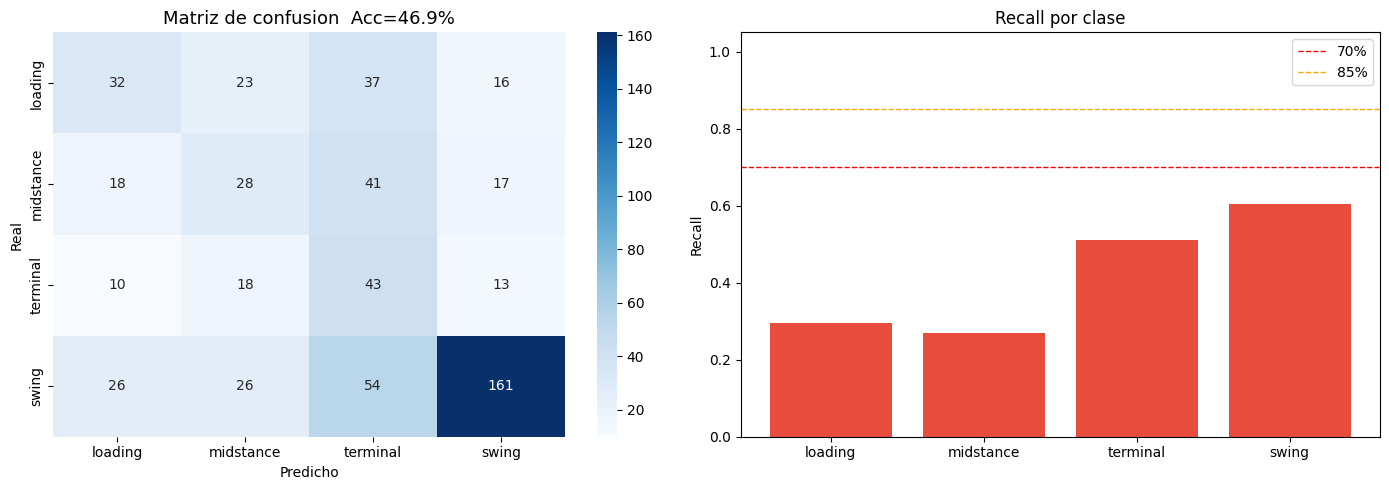


Reporte de clasificacion:
              precision    recall  f1-score   support

     loading      0.372     0.296     0.330       108
   midstance      0.295     0.269     0.281       104
    terminal      0.246     0.512     0.332        84
       swing      0.778     0.603     0.679       267

    accuracy                          0.469       563
   macro avg      0.423     0.420     0.406       563
weighted avg      0.531     0.469     0.487       563



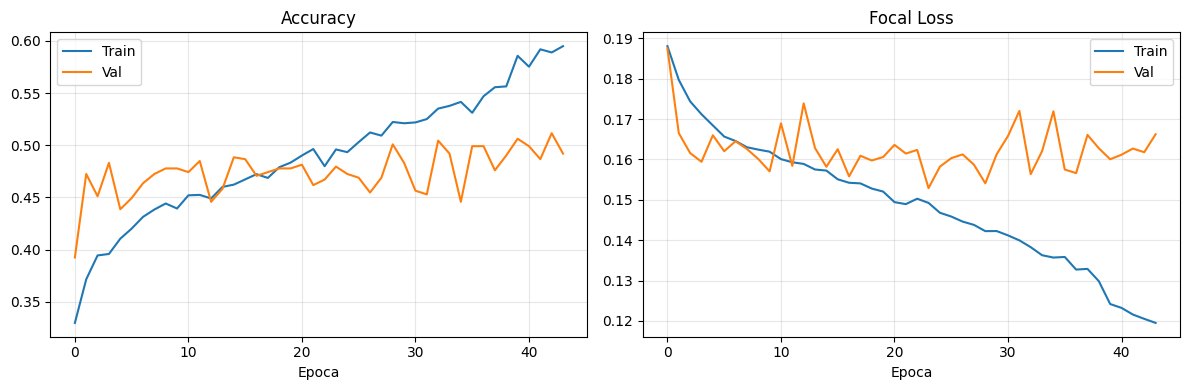

In [214]:
if len(X_test) == 0:
    print('Test set vacio, evaluando sobre val set')
    X_eval_in, y_eval_oh, y_eval = X_val_in, y_val_oh, y_val
else:
    X_eval_in, y_eval_oh, y_eval = X_test_in, y_test_oh, y_test

loss, acc = model.evaluate(X_eval_in, y_eval_oh, verbose=0)
print(f'Test Loss    : {loss:.4f}')
print(f'Test Accuracy: {acc:.4f} ({acc*100:.1f}%)')

y_pred_proba = model.predict(X_eval_in, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

cm = confusion_matrix(y_eval, y_pred, labels=list(range(N_CLASSES)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=PHASES, yticklabels=PHASES, ax=axes[0])
axes[0].set_title(f'Matriz de confusion  Acc={acc*100:.1f}%', fontsize=13)
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

per_class_recall = cm.diagonal() / cm.sum(axis=1).clip(min=1)
bar_colors = ['#e74c3c' if r < 0.70 else '#f39c12' if r < 0.85 else '#2ecc71'
              for r in per_class_recall]
axes[1].bar(PHASES, per_class_recall, color=bar_colors)
axes[1].axhline(0.70,  color='red',    ls='--', lw=1, label='70%')
axes[1].axhline(0.85,  color='orange', ls='--', lw=1, label='85%')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Recall por clase')
axes[1].set_ylabel('Recall')
axes[1].legend()
plt.tight_layout()
plt.show()

print('\nReporte de clasificacion:')
print(classification_report(
    y_eval, y_pred,
    labels=list(range(N_CLASSES)),
    target_names=PHASES, digits=3
))

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
if 'val_accuracy' in history.history:
    axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoca')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
if 'val_loss' in history.history:
    axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Focal Loss'); axes[1].set_xlabel('Epoca')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Conversión a TFLite (float32)

Convertimos el modelo Keras a formato TFLite sin cuantización. Este es el paso base antes de la cuantización int8.

In [215]:
float_tflite_path = os.path.join(MODELS_DIR, 'gait_2s_float.tflite')

converter_f32 = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float  = converter_f32.convert()

with open(float_tflite_path, 'wb') as f:
    f.write(tflite_float)

float_size_kb = len(tflite_float) / 1024
print(f'Modelo float32 guardado en: {float_tflite_path}')
print(f'Tamaño: {float_size_kb:.1f} KB')

INFO:tensorflow:Assets written to: /var/folders/0v/g33cdk793lx7s137c8h93w5h0000gn/T/tmplwprgle2/assets


INFO:tensorflow:Assets written to: /var/folders/0v/g33cdk793lx7s137c8h93w5h0000gn/T/tmplwprgle2/assets


Saved artifact at '/var/folders/0v/g33cdk793lx7s137c8h93w5h0000gn/T/tmplwprgle2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 12, 1), dtype=tf.float32, name='imu_image')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  4968797904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968807696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968807312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968805200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968805584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968808080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968805008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968799440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968807888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968795408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968801360: TensorSpec(sh

W0000 00:00:1779521968.755484  149251 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779521968.757032  149251 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1779521968.759968  149251 reader.cc:83] Reading SavedModel from: /var/folders/0v/g33cdk793lx7s137c8h93w5h0000gn/T/tmplwprgle2
I0000 00:00:1779521968.761923  149251 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1779521968.761929  149251 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/0v/g33cdk793lx7s137c8h93w5h0000gn/T/tmplwprgle2
I0000 00:00:1779521968.772770  149251 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1779521968.816577  149251 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/0v/g33cdk793lx7s137c8h93w5h0000gn/T/tmplwprgle2
I0000 00:00:1779521968.827527  149251 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 67562 microseconds.


## 11. Cuantización int8

Cuantización completa (pesos + activaciones) a int8 usando un dataset representativo de calibración. El modelo int8 es ~4× más pequeño y corre más rápido en hardware sin FPU.

Finalmente comparamos la accuracy float32 vs int8 sobre las mismas muestras de test.

In [216]:
int8_tflite_path = os.path.join(MODELS_DIR, 'gait_2s_int8.tflite')

# ── Dataset representativo ─────────────────────────────────────────────────
# Usamos X_train_in (ya tiene la dimension correcta para el modelo actual:
#   CNN2D      -> (N, 50, 12, 1)
#   multibranch -> lista [(N,50,6), (N,50,6)]  — primer elemento
N_CALIB = min(200, len(X_train_bal))
calib_idx  = np.random.choice(len(X_train_bal), N_CALIB, replace=False)

if isinstance(X_train_in, list):
    # multi-branch: yield una lista con ambas entradas
    calib_s1 = X_train_in[0][calib_idx].astype(np.float32)
    calib_s2 = X_train_in[1][calib_idx].astype(np.float32)
    def representative_dataset():
        for i in range(N_CALIB):
            yield [calib_s1[i:i+1], calib_s2[i:i+1]]
else:
    # cnn2d: (N, 50, 12, 1)
    calib_data = X_train_in[calib_idx].astype(np.float32)
    def representative_dataset():
        for i in range(N_CALIB):
            yield [calib_data[i:i+1]]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type  = tf.int8
converter_int8.inference_output_type = tf.int8

tflite_int8 = converter_int8.convert()

with open(int8_tflite_path, 'wb') as f:
    f.write(tflite_int8)

int8_size_kb = len(tflite_int8) / 1024
print(f'Modelo int8 guardado en: {int8_tflite_path}')
print(f'Tamano float32: {float_size_kb:.1f} KB')
print(f'Tamano int8   : {int8_size_kb:.1f} KB')
print(f'Compresion    : {float_size_kb/int8_size_kb:.1f}x')


INFO:tensorflow:Assets written to: /var/folders/0v/g33cdk793lx7s137c8h93w5h0000gn/T/tmphcf3ol0_/assets


INFO:tensorflow:Assets written to: /var/folders/0v/g33cdk793lx7s137c8h93w5h0000gn/T/tmphcf3ol0_/assets


Saved artifact at '/var/folders/0v/g33cdk793lx7s137c8h93w5h0000gn/T/tmphcf3ol0_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 12, 1), dtype=tf.float32, name='imu_image')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  4968797904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968807696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968807312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968805200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968805584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968808080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968805008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968799440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968807888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968795408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4968801360: TensorSpec(sh

W0000 00:00:1779521970.295432  149251 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779521970.295479  149251 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1779521970.295857  149251 reader.cc:83] Reading SavedModel from: /var/folders/0v/g33cdk793lx7s137c8h93w5h0000gn/T/tmphcf3ol0_
I0000 00:00:1779521970.297550  149251 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1779521970.297576  149251 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/0v/g33cdk793lx7s137c8h93w5h0000gn/T/tmphcf3ol0_
I0000 00:00:1779521970.313071  149251 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1779521970.377840  149251 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/0v/g33cdk793lx7s137c8h93w5h0000gn/T/tmphcf3ol0_
I0000 00:00:1779521970.394254  149251 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 98400 microseconds.


Modelo int8 guardado en: /Users/diegovillaba/Code/FusionGait/training/models/gait_2s_int8.tflite
Tamano float32: 41.8 KB
Tamano int8   : 18.3 KB
Compresion    : 2.3x


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1779521971.287303  149251 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [217]:
# Inferencia TFLite float32 vs int8 sobre test set
def run_tflite_inference(tflite_bytes, X_in, is_int8=False):
    """Run TFLite inference. X_in must already have the correct shape
    for the model (e.g. (N,50,12,1) for CNN2D or (N,50,6) for multibranch).
    """
    interp = tf.lite.Interpreter(model_content=tflite_bytes)
    interp.allocate_tensors()
    inp_det = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]

    preds = []
    for i in range(len(X_in)):
        sample = X_in[i:i+1].astype(np.float32)
        if is_int8:
            scale  = inp_det['quantization_parameters']['scales'][0]
            zp     = inp_det['quantization_parameters']['zero_points'][0]
            sample = (sample / scale + zp).astype(np.int8)
        interp.set_tensor(inp_det['index'], sample)
        interp.invoke()
        out = interp.get_tensor(out_det['index'])
        if is_int8:
            out_scale = out_det['quantization_parameters']['scales'][0]
            out_zp    = out_det['quantization_parameters']['zero_points'][0]
            out = (out.astype(np.float32) - out_zp) * out_scale
        preds.append(np.argmax(out))
    return np.array(preds)


# X_eval_in ya tiene la dimension correcta (asignada en la celda de evaluacion)
if len(X_eval_in) > 0 and not isinstance(X_eval_in, list):
    N_EVAL    = min(300, len(X_eval_in))
    idx_eval  = np.random.choice(len(X_eval_in), N_EVAL, replace=False)
    X_ev_sub  = X_eval_in[idx_eval]
    y_ev_sub  = y_eval[idx_eval]

    preds_f32 = run_tflite_inference(tflite_float, X_ev_sub, is_int8=False)
    acc_f32   = (preds_f32 == y_ev_sub).mean()

    preds_i8  = run_tflite_inference(tflite_int8, X_ev_sub, is_int8=True)
    acc_i8    = (preds_i8 == y_ev_sub).mean()

    print(f'Accuracy float32 TFLite : {acc_f32*100:.1f}%')
    print(f'Accuracy int8   TFLite  : {acc_i8*100:.1f}%')
    print(f'Degradacion cuantizacion: {(acc_f32-acc_i8)*100:.1f} pp')
else:
    print('Sin muestras escalares disponibles para benchmark TFLite')
    print('(multi-branch: lanza inferencia manual por sensor)')


Accuracy float32 TFLite : 50.7%
Accuracy int8   TFLite  : 48.7%
Degradacion cuantizacion: 2.0 pp


## 12. Exportar modelo como header C para Arduino

El modelo int8 se convierte a un array de bytes C que se incluye directamente en el sketch de Arduino con `#include "gait_model_2s.h"`.

El archivo `.h` contiene un array `const unsigned char` y su longitud.

In [218]:
def tflite_to_c_header(tflite_path, var_name, out_path, cols=12):
    """Convert a .tflite file to a C header with a byte array."""
    with open(tflite_path, 'rb') as f:
        data = f.read()

    hex_bytes = [f'0x{b:02x}' for b in data]
    # Group into lines of `cols` bytes
    lines = []
    for i in range(0, len(hex_bytes), cols):
        lines.append('  ' + ', '.join(hex_bytes[i:i+cols]))

    body = ',\n'.join(lines)
    header = (
        f'// Auto-generated by FusionGait training pipeline\n'
        f'// Model: {os.path.basename(tflite_path)}\n'
        f'// Size : {len(data)} bytes ({len(data)/1024:.1f} KB)\n'
        f'#ifndef {var_name.upper()}_H\n'
        f'#define {var_name.upper()}_H\n\n'
        f'const unsigned char {var_name}[] = {{\n'
        f'{body}\n'
        f'}};\n\n'
        f'const int {var_name}_len = {len(data)};\n\n'
        f'#endif // {var_name.upper()}_H\n'
    )
    with open(out_path, 'w') as f:
        f.write(header)
    return len(data)


c_header_path = os.path.join(MODELS_DIR, 'gait_model_2s.h')
n_bytes = tflite_to_c_header(
    tflite_path=int8_tflite_path,
    var_name='gait_model',
    out_path=c_header_path
)
print(f'Header C guardado: {c_header_path}')
print(f'Tamaño del modelo: {n_bytes} bytes ({n_bytes/1024:.1f} KB)')

# Preview first lines
with open(c_header_path) as f:
    preview = f.readlines()[:10]
print('\nPrimeras líneas del header:')
print(''.join(preview))

Header C guardado: /Users/diegovillaba/Code/FusionGait/training/models/gait_model_2s.h
Tamaño del modelo: 18744 bytes (18.3 KB)

Primeras líneas del header:
// Auto-generated by FusionGait training pipeline
// Model: gait_2s_int8.tflite
// Size : 18744 bytes (18.3 KB)
#ifndef GAIT_MODEL_H
#define GAIT_MODEL_H

const unsigned char gait_model[] = {
  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,
  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,
  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,



## 13. Parámetros de normalización para Arduino

El Arduino debe replicar exactamente la normalización aplicada durante el entrenamiento. Se exportan `mean` y `std` por canal como arrays C, y también como archivo `.npz` para carga en futuros notebooks.

In [219]:
scaler_mean = scaler.mean_.astype(np.float32)
scaler_std  = scaler.scale_.astype(np.float32)  # std (not var)

print(f'SCALER_MEAN shape: {scaler_mean.shape}')
print(f'SCALER_STD  shape: {scaler_std.shape}')

# ── C arrays ──────────────────────────────────────────────────────────────
def arr_to_c(arr, name, dtype='float'):
    vals = ', '.join(f'{v:.6f}f' for v in arr)
    return f'const {dtype} {name}[{len(arr)}] = {{{vals}}};'

mean_c = arr_to_c(scaler_mean, f'SCALER_MEAN')
std_c  = arr_to_c(scaler_std,  f'SCALER_STD')

print('\n// Paste these into your Arduino sketch:')
print(f'// Feature order: {FEAT_COLS}')
print(mean_c)
print(std_c)

# ── Save .npz ─────────────────────────────────────────────────────────────
npz_path = os.path.join(MODELS_DIR, 'scaler_params_2s.npz')
np.savez(npz_path,
         mean=scaler_mean,
         std=scaler_std,
         feature_cols=np.array(FEAT_COLS))
print(f'\nParámetros guardados en: {npz_path}')

SCALER_MEAN shape: (12,)
SCALER_STD  shape: (12,)

// Paste these into your Arduino sketch:
// Feature order: ['ax_s1', 'ay_s1', 'az_s1', 'gx_s1', 'gy_s1', 'gz_s1', 'ax_s2', 'ay_s2', 'az_s2', 'gx_s2', 'gy_s2', 'gz_s2']
const float SCALER_MEAN[12] = {-0.675642f, -0.004733f, -0.090318f, 0.813715f, -1.123366f, 3.726927f, -0.057511f, 0.126643f, -0.065969f, -1.168595f, -0.755900f, 2.168797f};
const float SCALER_STD[12] = {0.564111f, 0.588007f, 0.351765f, 47.664619f, 67.112335f, 65.470619f, 0.622693f, 0.977142f, 0.277153f, 42.067482f, 48.213253f, 118.562881f};

Parámetros guardados en: /Users/diegovillaba/Code/FusionGait/training/models/scaler_params_2s.npz


## 14. Plantilla de firmware Arduino — inference_node

### Arquitectura de despliegue

```
┌─────────────────────────────┐     BLE Notification
│  Arduino MASTER (tobillo)   │ ◄──────────────────────
│  sensor_id = 1              │                        │
│  - Lee BMI270 propio        │  ┌─────────────────────┴────┐
│  - Recibe datos esclavo     │  │  Arduino SLAVE (pierna)  │
│  - Rellena ring buffer      │  │  sensor_id = 2           │
│    (50 muestras × 12 feat.) │  │  - Lee BMI270 propio     │
│  - Cada 25 muestras:        │  │  - Notifica via BLE      │
│    → normaliza              │  └──────────────────────────┘
│    → corre TFLite int8      │
│    → imprime fase via Serial│
└─────────────────────────────┘
```

El sketch usa:
- `<TensorFlowLite.h>` (Arduino_TensorFlowLite library)
- `"gait_model_2s.h"` (generado en la celda 12)
- Ring buffer circular de `WINDOW_SIZE × N_FEATURES` floats
- Inferencia cada `STEP=25` muestras nuevas

Los parámetros `SCALER_MEAN` y `SCALER_STD` se copian de la celda 13.

In [220]:
# Generate the scaler constants to embed in the sketch
_mean_c_vals = ', '.join(f'{v:.6f}f' for v in scaler_mean)
_std_c_vals  = ', '.join(f'{v:.6f}f' for v in scaler_std)

arduino_sketch = f'''
// ============================================================
// FusionGait — inference_node.ino  (MASTER / tobillo)
// Generated by training/notebooks/gait_tinyml.ipynb
// Hardware: Arduino Nano 33 BLE Sense Rev2 (nRF52840 + BMI270)
// ============================================================
#include <Arduino_BMI270_BMM150.h>
#include <ArduinoBLE.h>
#include <TensorFlowLite.h>
#include <tensorflow/lite/micro/all_ops_resolver.h>
#include <tensorflow/lite/micro/micro_interpreter.h>
#include <tensorflow/lite/schema/schema_generated.h>
#include "gait_model_2s.h"   // auto-generated C header

// ── Hyperparameters ──────────────────────────────────────────
#define WINDOW_SIZE  50
#define N_FEATURES   12   // 6 per sensor × 2 sensors
#define STEP         25   // run inference every STEP new samples
#define N_CLASSES     4

// ── Normalisation (from scaler_params_2s.npz) ────────────────
// Feature order: ax_s1 ay_s1 az_s1 gx_s1 gy_s1 gz_s1
//                ax_s2 ay_s2 az_s2 gx_s2 gy_s2 gz_s2
const float SCALER_MEAN[{N_FEATURES}] = {{{_mean_c_vals}}};
const float SCALER_STD [{N_FEATURES}] = {{{_std_c_vals}}};

// ── TFLite setup ─────────────────────────────────────────────
const int TENSOR_ARENA_SIZE = 32 * 1024;  // adjust if needed
uint8_t tensor_arena[TENSOR_ARENA_SIZE];

const tflite::Model*              tfl_model   = nullptr;
tflite::MicroInterpreter*         interpreter = nullptr;
TfLiteTensor*                     input_tensor  = nullptr;
TfLiteTensor*                     output_tensor = nullptr;

// ── Ring buffer ───────────────────────────────────────────────
float window_buf[WINDOW_SIZE][N_FEATURES];  // circular buffer
int   buf_head   = 0;     // next write position
int   buf_count  = 0;     // samples filled so far
int   samples_since_inference = 0;

// ── BLE slave data ────────────────────────────────────────────
BLEDevice slave_device;
BLECharacteristic imu_char;
volatile float slave_ax=0, slave_ay=0, slave_az=0;
volatile float slave_gx=0, slave_gy=0, slave_gz=0;
volatile bool  slave_data_ready = false;

const char* PHASE_NAMES[N_CLASSES] = {{
    "loading", "midstance", "terminal", "swing"
}};

// ── BLE notification callback ─────────────────────────────────
void onSlaveNotify(BLEDevice device, BLECharacteristic characteristic) {{
    // Protocol: 6 floats = 24 bytes [ax, ay, az, gx, gy, gz]
    const uint8_t* raw = characteristic.value();
    if (characteristic.valueLength() == 6 * sizeof(float)) {{
        memcpy(&slave_ax, raw + 0*4, 4);
        memcpy(&slave_ay, raw + 1*4, 4);
        memcpy(&slave_az, raw + 2*4, 4);
        memcpy(&slave_gx, raw + 3*4, 4);
        memcpy(&slave_gy, raw + 4*4, 4);
        memcpy(&slave_gz, raw + 5*4, 4);
        slave_data_ready = true;
    }}
}}

// ── Normalise one sample in-place ─────────────────────────────
void normalise(float* sample, int n_feat) {{
    for (int i = 0; i < n_feat; i++) {{
        sample[i] = (sample[i] - SCALER_MEAN[i]) / (SCALER_STD[i] + 1e-8f);
    }}
}}

// ── Run TFLite inference ──────────────────────────────────────
int run_inference() {{
    // Fill input tensor from ring buffer (oldest first)
    int8_t* inp = input_tensor->data.int8;
    float   scale = input_tensor->params.scale;
    int32_t zp    = input_tensor->params.zero_point;

    for (int t = 0; t < WINDOW_SIZE; t++) {{
        int idx = (buf_head + t) % WINDOW_SIZE;
        for (int f = 0; f < N_FEATURES; f++) {{
            float q = window_buf[idx][f] / scale + zp;
            q = constrain(q, -128.0f, 127.0f);
            inp[t * N_FEATURES + f] = (int8_t)q;
        }}
    }}

    if (interpreter->Invoke() != kTfLiteOk) return -1;

    int8_t* out     = output_tensor->data.int8;
    float   o_scale = output_tensor->params.scale;
    int32_t o_zp    = output_tensor->params.zero_point;
    int     best    = 0;
    float   best_v  = -999.0f;
    for (int c = 0; c < N_CLASSES; c++) {{
        float v = (out[c] - o_zp) * o_scale;
        if (v > best_v) {{ best_v = v; best = c; }}
    }}
    return best;
}}

// ── setup() ──────────────────────────────────────────────────
void setup() {{
    Serial.begin(115200);
    while (!Serial);

    // IMU
    if (!IMU.begin()) {{
        Serial.println("ERROR: IMU init failed");
        while (1);
    }}

    // TFLite
    tfl_model = tflite::GetModel(gait_model);
    if (tfl_model->version() != TFLITE_SCHEMA_VERSION) {{
        Serial.println("ERROR: TFLite schema mismatch");
        while (1);
    }}
    static tflite::AllOpsResolver resolver;
    static tflite::MicroInterpreter static_interpreter(
        tfl_model, resolver, tensor_arena, TENSOR_ARENA_SIZE);
    interpreter = &static_interpreter;
    interpreter->AllocateTensors();
    input_tensor  = interpreter->input(0);
    output_tensor = interpreter->output(0);

    // BLE — connect to slave
    if (!BLE.begin()) {{
        Serial.println("ERROR: BLE init failed");
        while (1);
    }}
    BLE.scanForName("FusionGait_Slave");
    Serial.println("Buscando esclavo BLE...");
}}

// ── loop() ───────────────────────────────────────────────────
void loop() {{
    // 1. Poll BLE for slave device
    if (!slave_device) {{
        BLEDevice found = BLE.available();
        if (found) {{
            BLE.stopScan();
            slave_device = found;
            if (slave_device.connect()) {{
                slave_device.discoverAttributes();
                imu_char = slave_device.characteristic("2A58");
                if (imu_char) imu_char.subscribe();
                imu_char.setEventHandler(BLEValueUpdated, onSlaveNotify);
                Serial.println("Esclavo conectado");
            }}
        }}
        return;
    }}

    // 2. Read own IMU (master = tobillo = sensor 1)
    float ax1, ay1, az1, gx1, gy1, gz1;
    if (!IMU.accelerationAvailable() || !IMU.gyroscopeAvailable()) return;
    IMU.readAcceleration(ax1, ay1, az1);
    IMU.readGyroscope(gx1, gy1, gz1);

    // 3. Wait for slave data
    if (!slave_data_ready) return;
    slave_data_ready = false;

    // 4. Build one sample [ax_s1..gz_s1, ax_s2..gz_s2]
    float sample[N_FEATURES] = {{
        ax1, ay1, az1, gx1, gy1, gz1,
        slave_ax, slave_ay, slave_az, slave_gx, slave_gy, slave_gz
    }};
    normalise(sample, N_FEATURES);

    // 5. Write to ring buffer
    memcpy(window_buf[buf_head], sample, sizeof(sample));
    buf_head = (buf_head + 1) % WINDOW_SIZE;
    if (buf_count < WINDOW_SIZE) buf_count++;
    samples_since_inference++;

    // 6. Run inference every STEP samples once buffer is full
    if (buf_count == WINDOW_SIZE && samples_since_inference >= STEP) {{
        samples_since_inference = 0;
        int phase_id = run_inference();
        if (phase_id >= 0) {{
            Serial.print("PHASE:");
            Serial.println(PHASE_NAMES[phase_id]);
        }}
    }}
}}
'''

print(arduino_sketch)


// ============================================================
// FusionGait — inference_node.ino  (MASTER / tobillo)
// Generated by training/notebooks/gait_tinyml.ipynb
// Hardware: Arduino Nano 33 BLE Sense Rev2 (nRF52840 + BMI270)
// ============================================================
#include <Arduino_BMI270_BMM150.h>
#include <ArduinoBLE.h>
#include <TensorFlowLite.h>
#include <tensorflow/lite/micro/all_ops_resolver.h>
#include <tensorflow/lite/micro/micro_interpreter.h>
#include <tensorflow/lite/schema/schema_generated.h>
#include "gait_model_2s.h"   // auto-generated C header

// ── Hyperparameters ──────────────────────────────────────────
#define WINDOW_SIZE  50
#define N_FEATURES   12   // 6 per sensor × 2 sensors
#define STEP         25   // run inference every STEP new samples
#define N_CLASSES     4

// ── Normalisation (from scaler_params_2s.npz) ────────────────
// Feature order: ax_s1 ay_s1 az_s1 gx_s1 gy_s1 gz_s1
//                ax_s2 ay_s2 az_s2 gx_s2 gy

## Resumen de artefactos generados

| Archivo | Descripción |
|---------|-------------|
| `training/models/gait_2s_float.tflite` | Modelo TFLite float32 |
| `training/models/gait_2s_int8.tflite`  | Modelo TFLite int8 (para Arduino) |
| `training/models/gait_model_2s.h`      | Header C con modelo embebido |
| `training/models/scaler_params_2s.npz` | Media y std del escalador |

### Próximos pasos
1. Copiar `gait_model_2s.h` al directorio del sketch Arduino
2. Pegar las constantes `SCALER_MEAN`/`SCALER_STD` del paso 13 en el sketch
3. Ajustar `TENSOR_ARENA_SIZE` si hay errores de memoria en el Nano 33 BLE Sense
4. Para extender a 3 sensores: llamar `align_sensors(df, sensor_ids=[1,2,3])` y cambiar `N_FEATURES=18` en el sketch